# 01 · 从成分到性质：多任务预测模型

这是两节课教材的第一节。

| Notebook | 做什么 | 产出 |
|---|---|---|
| **01（本篇）** | 认识数据 → 把化学式变成特征 → 搭一个多任务模型 → 训练 → 评估 | 一个训练好的模型 checkpoint |
| **02** | 载入 01 的模型，用它做**逆向设计**：反过来求「什么成分能满足我要的性质」 | 三个设计场景的候选成分 + 可视化分析 |

## 正向 vs 逆向

这两节课其实是一件事的两个方向：

```
正向（本篇）：  成分  ──模型──▶  性质        “Mg42Zn50 的形成能是多少？”
逆向（下一篇）：性质  ──优化──▶  成分        “我要低形成能 + 高磁化，给我一个配方。”
```

逆向设计不是训练一个「反向模型」。它复用**同一个正向模型**，把成分当作可训练变量，
用梯度下降去调，直到模型预测出来的性质符合要求。所以：

> **正向模型的质量，直接决定逆向设计结果的可信度。**
> 这就是为什么必须先花一整节课把 01 做扎实——第 5 节的评估不是走过场，
> 它告诉你第二节课里哪些性质的设计结果值得相信、哪些只能当参考。

## 本篇不讲什么

- **不讲数据清洗**。原始数据来自四个不同的数据库，口径、单位、命名全不一样。
  整理的过程本身是另一个话题，这里已经提前做完了，结果就是 `data/` 下那一个 parquet 文件。
  想看怎么做的，读 `prepare_data.py`（有完整注释），但不需要跑。
- **不讲多任务学习本身**。我们确实同时训练 5 个任务，但那是因为第二节课的三个设计场景
  需要这 5 个性质，不是因为要研究「多任务比单任务好在哪」。共享 encoder 的动机会简单提一句，
  点到为止。

## 运行环境

```bash
uv sync --frozen --all-groups          # 在项目根目录执行一次，装好依赖
uv run jupyter lab                     # 然后打开本文件
```

整篇跑完约 **1–2 分钟**（CPU 即可，40 个 epoch）。

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning import Trainer, seed_everything
from loguru import logger
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, r2_score

from foundation_model.data.datamodule import CompoundDataModule
from foundation_model.models.flexible_multi_task_model import FlexibleMultiTaskModel
from foundation_model.models.model_config import (
    ClassificationTaskConfig,
    MLPEncoderConfig,
    OptimizerConfig,
    RegressionTaskConfig,
)
from foundation_model.utils.kmd_plus import DEFAULT_ELEMENTS, KMD, element_features, formula_to_composition

# 本教材目录。如果你从别处启动 Jupyter，把它改成绝对路径。
HERE = Path.cwd() if Path.cwd().name == "teaching_inverse_design" else Path("notebooks/teaching_inverse_design")
DATA_PATH = HERE / "data" / "qc_inverse_design_teaching.parquet"
OUT_DIR = HERE / "outputs"
OUT_DIR.mkdir(exist_ok=True)

# 建模型时库会把整个网络结构打进日志（几百行），静音掉，我们自己打简明版。
logger.remove()

# 图里一律用英文标签：matplotlib 的默认字体没有中文字形，换字体在不同机器上不可靠。
# 讲解在 markdown 里，图只放坐标轴。
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.3})
print("数据文件:", DATA_PATH, "->", "存在" if DATA_PATH.exists() else "找不到，请检查路径")

数据文件: /Users/liuchang/projects/foundation_model/notebooks/teaching_inverse_design/data/qc_inverse_design_teaching.parquet -> 存在


---
## 1 · 数据长什么样

一个 parquet 文件，一行 = 一个化学成分。

In [2]:
df = pd.read_parquet(DATA_PATH)
print(f"{len(df):,} 行 × {df.shape[1]} 列")
df.head(8)

29,802 行 × 8 列


,composition,split,material_type,material_type_name,formation_energy,magnetization,tc,klat
0,B1,test,0.0,AC,NaN,NaN,NaN,3.39452
1,B6.4 C1,train,0.0,AC,NaN,NaN,NaN,NaN
2,B6.5 C1,train,0.0,AC,NaN,NaN,NaN,NaN
3,B7.3 C1,val,0.0,AC,NaN,NaN,NaN,NaN
4,B12,train,0.0,AC,NaN,NaN,NaN,NaN
5,B104,val,0.0,AC,NaN,NaN,NaN,NaN
6,B105,train,0.0,AC,NaN,NaN,NaN,NaN
7,B105 W1,val,0.0,AC,NaN,NaN,NaN,NaN


### 1.1 每一列的含义

| 列 | 类型 | 含义 |
|---|---|---|
| `composition` | str | 化学成分，规范化写法（`"Mg2 Zn3"`）。**这是唯一的主键** |
| `split` | str | `train` / `val` / `test`，已经固定好，所有人跑出来的划分完全一致 |
| `material_type` | int | 分类标签：`0=AC`（近似晶体）、`1=QC`（**准晶**）、`2=others` |
| `material_type_name` | str | 同上，可读版本，画图用 |
| `formation_energy` | float | 形成能（每原子） |
| `magnetization` | float | 磁化强度 |
| `tc` | float | 超导转变温度 |
| `klat` | float | 晶格热导率 |

**四个性质列都是标准化（z-score）之后的值，不是物理单位。** 也就是说 `0` 大致是该性质的平均水平，
`+2` 意味着「比平均高两个标准差」。这一点在第二节课设置优化目标时会直接用到：
我们会写 `formation_energy = -2.0`，意思是「往低了压两个标准差」，而不是「-2 eV/atom」。

`QC`（准晶，quasicrystal）是本教材的主角。准晶是一类既不是晶体也不是非晶的特殊结构，
稀少而难合成——第二节课的三个设计场景，**每一个**都要求「让模型认为它是准晶」。

### 1.2 关键事实一：大量缺失，而且是正常的

四个性质来自四个不同的数据库，它们覆盖的成分基本不重叠。所以任何一行都只有一部分列有值。

In [3]:
TASKS = ["formation_energy", "magnetization", "tc", "klat", "material_type"]

coverage = pd.DataFrame({
    "有标注行数": [int(df[t].notna().sum()) for t in TASKS],
    "占比": [f"{df[t].notna().mean():.1%}" for t in TASKS],
}, index=TASKS)
coverage["train / val / test"] = [
    " / ".join(str(int(n)) for n in df.loc[df[t].notna(), "split"].value_counts().reindex(["train", "val", "test"]).fillna(0))
    for t in TASKS
]
display(coverage)

n_labels = df[TASKS].notna().sum(axis=1)
print("\n每行有几个标注：")
print(n_labels.value_counts().sort_index().rename("行数").to_string())

,有标注行数,占比,train / val / test
formation_energy,8368,28.1%,5815 / 1273 / 1280
magnetization,1626,5.5%,1135 / 268 / 223
tc,10458,35.1%,7313 / 1600 / 1545
klat,5881,19.7%,4054 / 925 / 902
material_type,12361,41.5%,8509 / 1878 / 1974



每行有几个标注：
1    21269
2     8181
3      345
4        7


绝大多数行只有 1 个标注。**这不需要处理成「完整表格」。**

模型对每个任务都单独维护一个 mask：某一行在某个任务上是 NaN，
这一行就不参与那个任务的 loss，但**照样参与其他任务的 loss，也照样更新共享的 encoder**。
所以一行只有一个标注的样本并不浪费——它仍然在教 encoder「这个成分长什么样」。

这也是把 5 个任务放一起训练的实际理由：单独训练 `magnetization`（只有 1626 条）会严重过拟合，
但让它和一万多条 `tc`、八千多条 `formation_energy` 共享同一个 encoder，
encoder 见过的成分就多得多了。

### 1.3 关键事实二：分类标签极度不平衡

material_type_name
others    11995
QC          227
AC          139 

少数类占比: 2.96%


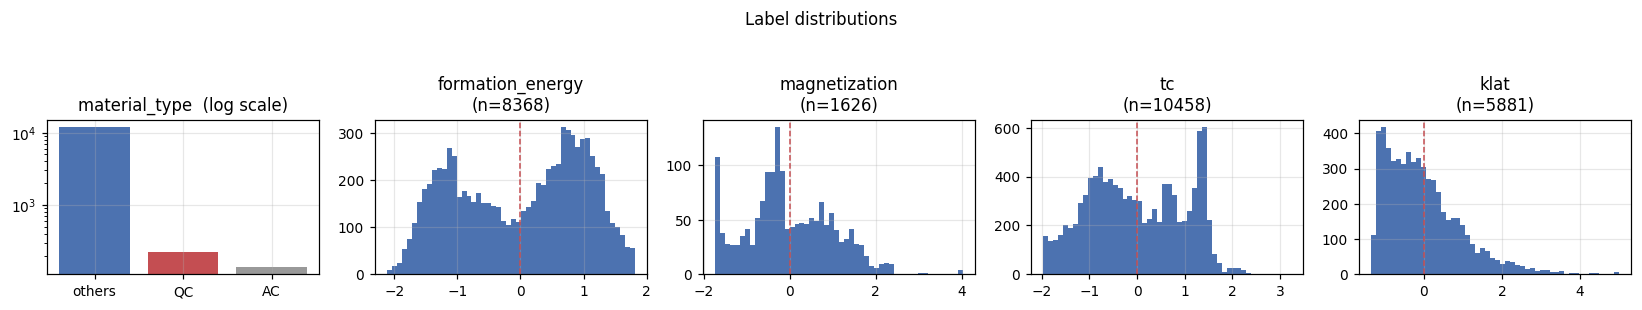

In [4]:
counts = df["material_type_name"].value_counts()
print(counts.to_string(), f"\n\n少数类占比: {counts[['AC', 'QC']].sum() / counts.sum():.2%}")

fig, axes = plt.subplots(1, 5, figsize=(15, 2.6))
axes[0].bar(counts.index, counts.values, color=["#4C72B0", "#C44E52", "#999999"])
axes[0].set_yscale("log")
axes[0].set_title("material_type  (log scale)")
for ax, col in zip(axes[1:], ["formation_energy", "magnetization", "tc", "klat"]):
    ax.hist(df[col].dropna(), bins=50, color="#4C72B0")
    ax.set_title(f"{col}\n(n={df[col].notna().sum()})")
    ax.axvline(0, color="#C44E52", lw=1, ls="--")
fig.suptitle("Label distributions", y=1.06)
fig.tight_layout()
plt.show()

12 361 个有分类标签的成分里，只有 **367** 个是 AC 或 QC，其余 12 000 个都是 `others`——
比例接近 **1 : 33**。

如果什么都不做，分类器把所有样本都预测成 `others` 就能拿到 97% 的准确率，
而 QC 的召回率是 0。这对我们是致命的：第二节课的每个场景都在优化「P(QC) 尽量高」，
如果分类头根本不会说 QC，整个逆向设计就是在优化一个常数。

处理办法在第 3 节：给交叉熵加**类别权重**，让少数类的每个样本在 loss 里更值钱。
第 5 节我们会专门看 QC 的召回率，而不是只看总体准确率。

---
## 2 · 从化学式到特征向量：KMD 描述符

神经网络吃的是**定长实数向量**，而 `"Mg42 Zn50"` 是一个字符串。中间需要一座桥。

这一节要讲的 KMD（Kernel Mean Descriptor，核均值描述符）就是这座桥。
**请认真读这一节**——它不只是「特征工程」，它的一个数学性质是第二节课整个逆向设计能成立的前提。

### 2.1 两步走

```
"Mg42 Zn50"  ──①──▶  w ∈ R^94   ──②──▶  x = w @ K ∈ R^464
   化学式             原子分数向量          KMD 描述符（喂给模型）
```

**① 化学式 → 原子分数向量 `w`**
固定一个 94 元素的顺序表（H, He, Li, …, Pu）。`w[j]` 就是第 j 号元素的原子分数。
`"Mg42 Zn50"` 里 Mg 占 42/92，Zn 占 50/92，其余 92 个位置全是 0。
所以 `w` 非负、加起来等于 1——用几何语言说，**`w` 是 94 维单纯形（simplex）上的一个点**。

**② `w` → 描述符 `x`**
每个元素本身有 58 个属性（原子半径、电负性、熔点……），组成一张固定的表
`element_features`，形状 `(94, 58)`。KMD 把这张表预先加工成一个**核基矩阵 `K`**，
形状 `(94, 464)`，然后：

$$x = w K$$

就这么简单——一次矩阵乘法。

> `464 = 58 × 8`：对 58 个元素属性中的每一个，在其取值范围上铺 `n_grids=8` 个高斯核，
> 分别问「这个配方在这个属性上的分布，在这 8 个位置各有多少质量」。
> 换句话说，KMD 描述的不是「平均电负性是多少」，而是「电负性的整个分布长什么样」——
> 比简单加权平均保留了更多信息（比如能区分「两个中等电负性元素」和「一高一低两个元素」）。

In [5]:
N_GRIDS = 8
kmd = KMD(element_features.values, method="1d", n_grids=N_GRIDS, sigma="auto", scale=True)

print(f"元素属性表 element_features: {element_features.shape}  (94 个元素 × 58 个属性)")
print(f"元素顺序表前 10 个: {DEFAULT_ELEMENTS[:10]}")

demo = "Mg42 Zn50"
w_demo = formula_to_composition(demo)
x_demo = kmd.transform(w_demo[None, :])

print(f"\n① {demo!r} -> w，形状 {w_demo.shape}，非零项:")
for j in np.nonzero(w_demo)[0]:
    print(f"      w[{j:2d}] = {w_demo[j]:.4f}   ({DEFAULT_ELEMENTS[j]})")
print(f"   w.sum() = {w_demo.sum():.6f}   <- 单纯形约束")
print(f"\n② w @ K -> x，形状 {x_demo.shape}，前 6 维: {np.round(x_demo[0, :6], 4)}")

元素属性表 element_features: (94, 58)  (94 个元素 × 58 个属性)
元素顺序表前 10 个: ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne']

① 'Mg42 Zn50' -> w，形状 (94,)，非零项:
      w[11] = 0.4565   (Mg)
      w[29] = 0.5435   (Zn)
   w.sum() = 1.000000   <- 单纯形约束

② w @ K -> x，形状 (1, 464)，前 6 维: [2.346e-01 5.774e-01 6.412e-01 2.828e-01 2.000e-02 2.000e-04]


### 2.2 为什么这一步决定了第二节课能不能做

盯着这个式子看：

$$x = w K \qquad (K \text{ 是常数矩阵})$$

**`x` 对 `w` 是线性的。** 于是整条从配方到预测的链路：

```
w ──(线性)──▶ x ──(神经网络)──▶ latent ──(tanh)──▶ h ──(各个 head)──▶ 预测性质
```

**从头到尾处处可微**。这意味着我们可以对「预测的性质和目标的差距」求梯度，
一路反传回 `w`，然后像训练网络参数一样去**更新配方本身**。

这正是第二节课要做的事。如果描述符是不可微的（比如查表、离散指纹、图结构的离散化处理），
逆向设计就只能退化成「枚举 + 筛选」或者「训练一个额外的生成模型」，两者都要麻烦得多。

> 顺便说一句，`KMD` 还提供 `.inverse()`：给定一个描述符 `x`，用二次规划反解出 `w`。
> 另一条逆向设计路线（latent 路径）需要它。**本教材不走那条路**——原因在 02 里讲。

In [6]:
# 一次性把全部成分的描述符算好。29 802 个成分只要几秒——因为核心就是一次矩阵乘法。
t0 = time.perf_counter()
compositions = df["composition"].tolist()
W_all = np.stack([formula_to_composition(c) for c in compositions])
X_all = kmd.transform(W_all)
X_DIM = X_all.shape[1]
descriptors = pd.DataFrame(X_all, index=compositions)
print(f"W {W_all.shape} -> X {X_all.shape}，耗时 {time.perf_counter() - t0:.1f} 秒")
print(f"X_DIM = {X_DIM}  <- 这就是 encoder 的输入维度")


def descriptor_fn(comps: list[str]) -> pd.DataFrame:
    '''DataModule 通过这个回调拿描述符：给一批成分，返回以成分为索引的描述符表。'''
    return descriptors.loc[[c for c in comps if c in descriptors.index]]

W (29802, 94) -> X (29802, 464)，耗时 0.9 秒
X_DIM = 464  <- 这就是 encoder 的输入维度


---
## 3 · 搭模型

### 3.1 结构

```
                                        ┌──▶ formation_energy  (回归, 1 维输出)
                                        ├──▶ magnetization     (回归, 1 维输出)
x ──▶ FoundationEncoder ──▶ latent ─tanh─┼──▶ tc               (回归, 1 维输出)
(464)      MLP 464→256→128      (128)    ├──▶ klat             (回归, 1 维输出)
                                        └──▶ material_type     (分类, 3 维 logits)
```

一个**共享的 encoder**，五个**各自独立的 head**。

共享 encoder 的作用，用第 1.2 节的数字说最清楚：`magnetization` 只有 1626 条标注，
单独训练很容易背下来；但 encoder 是被全部 29 802 个成分（通过五个任务的合力）
一起塑造的，`magnetization` 的 head 只需要在这个已经很像样的表示上再学一个薄薄的映射。

`tanh` 把 latent 压到 `[-1, 1]`。位置在**模型层面**，不在 encoder 内部——
记住这点，第二节课的计算图里会再次看到它。

### 3.2 处理类别不平衡

给交叉熵加类别权重：权重 ∝ 1 / 该类样本数。少数类的每个样本在 loss 里被放大约 30–100 倍，
模型就不能靠「一律猜 others」蒙混过关了。

In [7]:
CLASSES = ("AC", "QC", "others")
QC_CLASS_INDEX = CLASSES.index("QC")   # = 1，第二节课会反复用到

train_counts = df.loc[df["split"] == "train", "material_type"].value_counts()
class_weights = [float(train_counts.sum() / (len(CLASSES) * train_counts.get(i, 1))) for i in range(len(CLASSES))]
for name, n, w in zip(CLASSES, [int(train_counts.get(i, 0)) for i in range(3)], class_weights):
    print(f"  {name:8s} train 样本 {n:6d}   权重 {w:8.2f}")

  AC       train 样本     86   权重    32.98
  QC       train 样本    110   权重    25.78
  others   train 样本   8313   权重     0.34


### 3.3 任务配置

每个 head 用一个 dataclass 描述。`dims` 是 head 内部的层宽：
`[latent_dim, hidden, out]`。回归 head 的 `out=1`；分类 head 这里写 `32`，
是最后一层隐藏层的宽度，真正的 3 维 logits 由 `num_classes` 决定。

In [8]:
LATENT_DIM, ENCODER_HIDDEN, HEAD_HIDDEN = 128, 256, 64
LR, BATCH_SIZE, MAX_EPOCHS, SEED = 5e-3, 256, 40, 2025
REG_TASKS = ["formation_energy", "magnetization", "tc", "klat"]
CLF_TASK = "material_type"

task_configs = [
    RegressionTaskConfig(
        name=name,
        data_column=name,                              # 任务数据表里取哪一列当标签
        dims=[LATENT_DIM, HEAD_HIDDEN, 1],
        optimizer=OptimizerConfig(lr=LR, weight_decay=1e-5),
    )
    for name in REG_TASKS
] + [
    ClassificationTaskConfig(
        name=CLF_TASK,
        data_column=CLF_TASK,
        dims=[LATENT_DIM, HEAD_HIDDEN, 32],
        num_classes=len(CLASSES),
        class_weights=class_weights,                   # 上一格算出来的
        optimizer=OptimizerConfig(lr=LR, weight_decay=1e-5),
    )
]
for cfg in task_configs:
    print(f"  {cfg.name:18s} {type(cfg).__name__}")

  formation_energy   RegressionTaskConfig
  magnetization      RegressionTaskConfig
  tc                 RegressionTaskConfig
  klat               RegressionTaskConfig
  material_type      ClassificationTaskConfig


### 3.4 五个 loss 怎么加起来？

五个任务的 loss 量纲完全不同：回归是均方误差（~1 的量级），分类是交叉熵（~0.1–1）。
直接相加，谁大谁说了算，这不合理。

模型提供 **homoscedastic uncertainty weighting**（Kendall et al. 2018）——
默认**关着**，我们显式打开（下一格的 `enable_learnable_loss_balancer=True`）。
它为每个任务学一个可训练的 $\log\sigma_t$，最终 loss 是

$$\mathcal{L} = \sum_t \left[ \tfrac{1}{2} w_t\, e^{-2\log\sigma_t}\, \mathcal{L}_t + \log\sigma_t \right]$$

直觉：$\sigma_t$ 是模型对任务 $t$ 的「不确定度」。噪声大、学不动的任务，$\sigma_t$ 会自动变大，
$e^{-2\log\sigma_t}$ 就把它的权重压下去；后面的 `+ log σ_t` 是防止模型偷懒把所有 σ 推到无穷大的正则项。

**你不用手调五个权重**，这是它最大的好处。关掉它的话，就退化成
$\sum_t w_t \mathcal{L}_t$，$w_t$ 是每个任务配置里静态的 `loss_weight`（默认都是 1.0），
你得自己去平衡量纲。

In [9]:
seed_everything(SEED, workers=True)

model = FlexibleMultiTaskModel(
    task_configs=task_configs,
    encoder_config=MLPEncoderConfig(hidden_dims=[X_DIM, ENCODER_HIDDEN, LATENT_DIM]),
    enable_autoencoder=False,              # 见下方说明
    enable_learnable_loss_balancer=True,   # 打开上面讲的 homoscedastic 自动加权（默认是 False）
    shared_block_optimizer=OptimizerConfig(lr=LR, weight_decay=1e-2),
)
n_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {n_params:,}")
print(f"encoder   : {X_DIM} -> {ENCODER_HIDDEN} -> {LATENT_DIM}  (+ tanh)")
for name, head in model.task_heads.items():
    print(f"  head {name:18s} {type(head).__name__}")

Seed set to 2025


模型参数量: 197,132
encoder   : 464 -> 256 -> 128  (+ tanh)
  head formation_energy   RegressionHead
  head magnetization      RegressionHead
  head tc                 RegressionHead
  head klat               RegressionHead
  head material_type      ClassificationHead


> **`enable_autoencoder=False` 是一个有意的选择。**
> 这个模型可以额外挂一个自编码器头，把 latent 解码回描述符 `x`。
> 另一条逆向设计路线（在 latent 空间里优化，再解码回成分）**必须**要它。
> 我们走的 KMD 成分路径直接优化 `w`，不需要解码这一步，所以关掉它，
> 模型更小、训练更快、要讲的东西更少。第二节课第 2 节会说清楚为什么可以这样。

### 3.5 DataModule

`CompoundDataModule` 是**以成分为主键**的：每个任务给它一张
「索引 = 成分、列 = 标签 + split」的表，它负责取并集、算描述符、切分、组 batch、生成 mask。

In [10]:
task_frames = {}
for name in REG_TASKS + [CLF_TASK]:
    frame = pd.DataFrame({name: df[name].to_numpy(), "split": df["split"].to_numpy()}, index=compositions)
    task_frames[name] = frame.loc[frame[name].notna()]      # 只保留该任务有标注的行
    print(f"  {name:18s} {len(task_frames[name]):6d} 行")

datamodule = CompoundDataModule(
    task_configs=task_configs,
    descriptor_fn=descriptor_fn,
    task_frames=task_frames,
    composition_column="composition",
    random_seed=42,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

  formation_energy     8368 行
  magnetization        1626 行
  tc                  10458 行
  klat                 5881 行
  material_type       12361 行


---
## 4 · 训练

标准 Lightning 流程。40 个 epoch，CPU 上约 1 分钟。

In [11]:
trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=True,
)
t0 = time.perf_counter()
trainer.fit(model, datamodule=datamodule)
print(f"\n训练耗时 {time.perf_counter() - t0:.0f} 秒")

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


/Users/liuchang/projects/foundation_model/.venv/lib/python3.13/site-packages/pymatgen/core/composition.py:373: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda sym: get_el_sp(sym).X)
/Users/liuchang/projects/foundation_model/.venv/lib/python3.13/site-packages/pymatgen/core/composition.py:373: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda sym: get_el_sp(sym).X)
/Users/liuchang/projects/foundation_model/.venv/lib/python3.13/site-packages/pymatgen/core/composition.py:373: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms = sorted(sym_amt, key=lambda sym: g

/Users/liuchang/projects/foundation_model/.venv/lib/python3.13/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.

  | Name                | Type              | Params | Mode 
------------------------------------------------------------------
0 | task_log_sigmas     | ParameterDict     | 5      | train
1 | encoder             | FoundationEncoder | 152 K  | train
2 | task_heads          | ModuleDict        | 44.4 K | train
3 | disabled_task_heads | ModuleDict        | 0      | train
4 | val_r2_metrics      | ModuleDict        | 0      | train
5 | test_r2_metrics     | ModuleDict        | 0      | train
------------------------------------------------------------------
197 K     Trainable params
0         Non-trainable params
197 K     Total params
0.789     Total estimated model params size (MB)
74        Modules in train mode
0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Epoch 39: 100%|██████████| 81/81 [00:01<00:00, 51.30it/s, train_final_loss_step=-0.573, val_final_loss=-0.128, train_final_loss_epoch=-0.705]

Epoch 39: 100%|██████████| 81/81 [00:01<00:00, 51.24it/s, train_final_loss_step=-0.573, val_final_loss=-0.128, train_final_loss_epoch=-0.735]

`Trainer.fit` stopped: `max_epochs=40` reached.


Epoch 39: 100%|██████████| 81/81 [00:01<00:00, 51.21it/s, train_final_loss_step=-0.573, val_final_loss=-0.128, train_final_loss_epoch=-0.735]


训练耗时 66 秒


> 训练日志里的 `val_final_loss` 是**五个任务加权之后的总 loss**，
> 它下降说明整体在变好，但看不出是哪个任务在变好。
> 真正要看的是下一节按任务拆开的指标。

---
## 5 · 评估

这一节的目的**不是**给模型打分交差，而是回答一个具体问题：

> 第二节课要用这个模型当「评委」去挑成分。这五个 head，哪几个的话可以信？

只在 **test** 集上评估。注意用的是 DataModule **实际解析出来**的划分
（`datamodule.split_series`），而不是原始表里的 `split` 列——
DataModule 会把各任务的 split 叠加成一个统一的成分级划分，两者可能有出入。

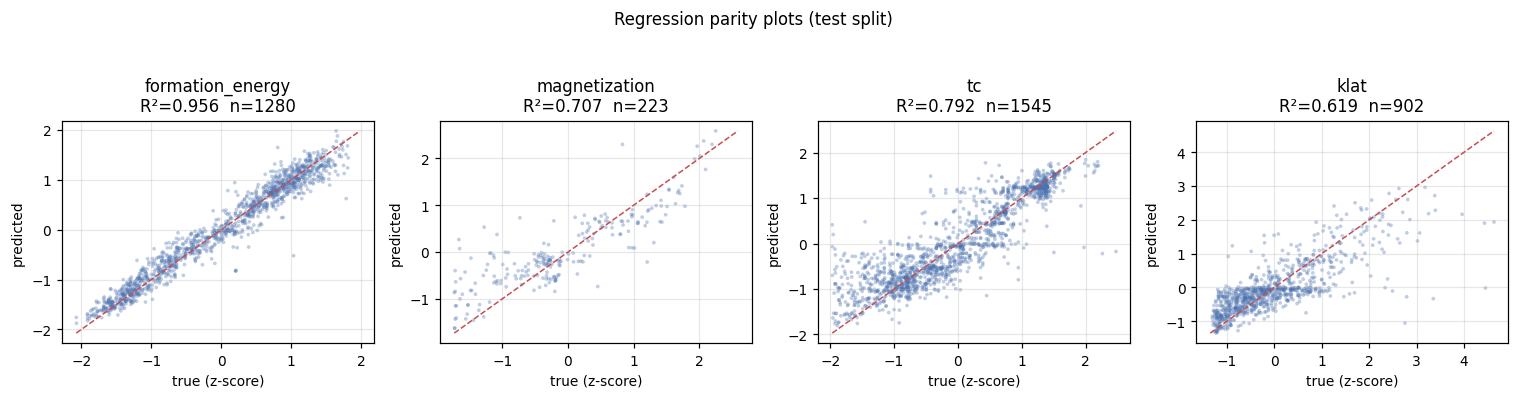

,n_test,R²,MAE
task,,,
formation_energy,1280,0.956,0.157
magnetization,223,0.707,0.398
tc,1545,0.792,0.320
klat,902,0.619,0.429


In [12]:
model.eval().to("cpu")
split = datamodule.split_series           # 成分 -> train/val/test
test_set = set(split.index[split == "test"])


def predict(comps: list[str]) -> dict[str, torch.Tensor]:
    x = torch.tensor(descriptors.loc[comps].values, dtype=torch.float32)
    with torch.no_grad():
        return model(x)


rows = []
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, name in zip(axes, REG_TASKS):
    comps = [c for c in task_frames[name].index if c in test_set]
    true = task_frames[name].loc[comps, name].to_numpy(float)
    pred = predict(comps)[name].squeeze(-1).numpy()
    r2, mae = r2_score(true, pred), mean_absolute_error(true, pred)
    rows.append({"task": name, "n_test": len(comps), "R²": round(r2, 3), "MAE": round(mae, 3)})

    ax.scatter(true, pred, s=6, alpha=0.35, color="#4C72B0", edgecolors="none")
    lim = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lim, lim, color="#C44E52", lw=1, ls="--")
    ax.set_title(f"{name}\nR²={r2:.3f}  n={len(comps)}")
    ax.set_xlabel("true (z-score)")
    ax.set_ylabel("predicted")
fig.suptitle("Regression parity plots (test split)", y=1.05)
fig.tight_layout()
plt.show()

reg_metrics = pd.DataFrame(rows).set_index("task")
display(reg_metrics)

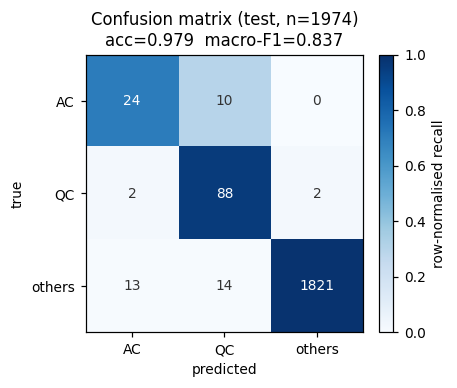

  AC       召回率 0.706   (test 集里有 34 个)
  QC       召回率 0.957   (test 集里有 92 个)
  others   召回率 0.985   (test 集里有 1848 个)


In [13]:
comps = [c for c in task_frames[CLF_TASK].index if c in test_set]
true = task_frames[CLF_TASK].loc[comps, CLF_TASK].to_numpy(int)
logits = predict(comps)[CLF_TASK]
pred = logits.argmax(dim=1).numpy()

acc = accuracy_score(true, pred)
macro_f1 = f1_score(true, pred, average="macro")
cm = confusion_matrix(true, pred, labels=range(len(CLASSES)))
recall = cm.diagonal() / np.clip(cm.sum(axis=1), 1, None)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), CLASSES); ax.set_yticks(range(3), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.grid(False)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] / max(cm[i].sum(), 1) > 0.5 else "#333")
ax.set_title(f"Confusion matrix (test, n={len(comps)})\nacc={acc:.3f}  macro-F1={macro_f1:.3f}")
fig.colorbar(im, ax=ax, label="row-normalised recall", fraction=0.046)
fig.tight_layout()
plt.show()

for name, r, n in zip(CLASSES, recall, cm.sum(axis=1)):
    print(f"  {name:8s} 召回率 {r:.3f}   (test 集里有 {n} 个)")

### 5.1 怎么读这些数字

**四个回归 head 的可信度差得很远，而且原因很明确——看 `n_test` 和第 1.2 节的标注量：**

- `formation_energy` R² 最高。标注最规整（同一个数据库、同一套计算口径），
  而且它和成分的关系相对直接。第二节课的三个场景都用它当目标，是有底气的。
- `tc`、`klat` 中等。数据来自实验/计算数据库，噪声大得多。
- `magnetization` 最弱，只有 1626 条标注，其中 test 集里才两百多条。
  第二节课的 scenario 1、2 会用它当目标——**结果要打折扣看**，
  这不是回避，而是逆向设计里必须诚实交代的一件事：
  优化器只会去满足模型说的话，模型说错了它照样一路优化过去。

**分类 head：别看总体准确率。**
`others` 占了 97%，全猜 `others` 也有 97% 的 acc。要看的是 **QC 的召回率**——
只有它高，第二节课「把 P(QC) 推高」这个目标才有意义。
macro-F1 同理，它把三个类别一视同仁地平均。

> **一个贯穿两节课的提醒**：逆向设计给出的成分是**模型认为**满足要求的成分，
> 不是自然界保证满足要求的成分。它的价值在于把「几百万种可能配方」缩小到
> 「几十个值得进实验室试一试的配方」，而不是替代实验。

---
## 6 · 保存，交给第二节课

02 需要三样东西：模型权重、一点元信息、以及 DataModule 解析出来的划分
（这样 02 挑种子时能保证只从 test 集里挑，不会用到训练时见过的成分）。

In [14]:
ckpt_path = OUT_DIR / "multitask_model.ckpt"
trainer.save_checkpoint(ckpt_path)

meta = {
    "x_dim": X_DIM,
    "n_grids": N_GRIDS,
    "latent_dim": LATENT_DIM,
    "reg_tasks": REG_TASKS,
    "clf_task": CLF_TASK,
    "classes": list(CLASSES),
    "qc_class_index": QC_CLASS_INDEX,
    "max_epochs": MAX_EPOCHS,
    "seed": SEED,
    "test_metrics": {
        **{r["task"]: {"R2": r["R²"], "MAE": r["MAE"], "n_test": r["n_test"]} for r in rows},
        "material_type": {"accuracy": round(float(acc), 4), "macro_f1": round(float(macro_f1), 4),
                          "recall_per_class": {c: round(float(v), 4) for c, v in zip(CLASSES, recall)}},
    },
}
(OUT_DIR / "model_meta.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
split.to_frame("split").to_parquet(OUT_DIR / "resolved_split.parquet")

for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size / 1024:8.1f} KB")

  model_meta.json                   0.8 KB
  multitask_model.ckpt           2387.8 KB
  resolved_split.parquet          371.6 KB


---
## 小结

1. 一个 parquet、一个主键（成分）、四个性质 + 一个类别标签，**大量缺失是常态**，靠 mask 处理。
2. **KMD 把化学式变成描述符，而且这一步是线性的** —— 这是第二节课能对成分求梯度的前提。
3. 共享 encoder + 五个独立 head；loss 权重由 homoscedastic uncertainty 自动学，不用手调。
4. 类别不平衡靠类别权重压，评估时看 **QC 召回率**而不是总体准确率。
5. 评估的真正用途：**给第二节课的每个设计目标标上可信度**。

### 想动手改改看

- 把 `enable_autoencoder` 打开，对比参数量和各任务 R²，看看重构任务对 encoder 是帮助还是干扰。
- 把 `class_weights` 换成 `None` 重训，观察 QC 召回率会掉到多少。
- `N_GRIDS` 从 8 改成 4 或 16（`X_DIM` 会跟着变），看描述符分辨率对各任务的影响。
- 只用 `magnetization` 一个任务单独训练一个模型，和这里的多任务版本比 R²。

**➡️ 接下来打开 `02_inverse_design.ipynb`。**